# Análisis de resultados de experimentos computacionales

In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import csv
import math
from matplotlib.gridspec import GridSpec

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.dpi'] = 300

---

### Lectura, Extracción y Almacenamiento de resultados

In [2]:
RESULTS_DIR = "../Results"
ALGORITMOS = ["CLASSIC", "QLEARNING"]
RUTA_TIEMPOS = os.path.join(RESULTS_DIR, "tiempos_ejecucion_limpios.csv")
CACHE_FILE = "df_master_cache.csv"

if os.path.exists(CACHE_FILE):
    print(f"Caché encontrado. Cargando datos directamente desde '{CACHE_FILE}'...")
    df_master = pd.read_csv(CACHE_FILE)
    print(f"Total de filas cargadas: {len(df_master)}")

else:
    print("No hay caché. Iniciando la lectura masiva optimizada...")
    datos_experimentos = []
    
    for algo in ALGORITMOS:
        path_busqueda = os.path.join(RESULTS_DIR, algo, "metrics", "*.csv")
        archivos_csv = glob.glob(path_busqueda)
        
        for ruta_archivo in archivos_csv:
            nombre_archivo = os.path.basename(ruta_archivo)
            partes = nombre_archivo.replace(".csv", "").split("_")
            
            if len(partes) >= 4:
                instancia = partes[1]
                run_id = partes[3].replace("run", "")
                
                try:
                    df_run = pd.read_csv(ruta_archivo)
                    if not df_run.empty:
                        ultima_fila = df_run.iloc[-1]
                        final_veh = ultima_fila['best_veh']
                        final_dist = ultima_fila['best_dist']
                        idx_convergencia = df_run[(df_run['best_veh'] == final_veh) & 
                                                  (df_run['best_dist'] == final_dist)].index[0]
                        iter_optimo = df_run.loc[idx_convergencia, 'iter']
                        datos_experimentos.append({
                            "Algoritmo": algo,
                            "Instancia": instancia.lower(),
                            "Run": int(run_id),
                            "Vehiculos": final_veh,      
                            "Distancia": final_dist,     
                            "Iter_Convergencia": iter_optimo
                        })
                except Exception as e:
                    print(f"[ERROR] En {nombre_archivo}: {e}")

    df_master = pd.DataFrame(datos_experimentos)
    print(f"Extracción completada: {len(df_master)} corridas procesadas.")

    try:
        df_tiempos = pd.read_csv(RUTA_TIEMPOS)
        df_tiempos['Instancia'] = df_tiempos['Instancia'].astype(str).str.lower().str.strip()
        
        df_master = pd.merge(df_master, df_tiempos, on=['Instancia', 'Algoritmo', 'Run'], how='inner')
        print("=== INTEGRACIÓN DE TIEMPOS COMPLETADA ===")
        print(f"Total de filas consolidadas: {len(df_master)}")

        df_master.to_csv(CACHE_FILE, index=False)
        print(f"Datos guardados exitosamente en '{CACHE_FILE}'. La próxima ejecución será instantánea.")
        
    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo en: {RUTA_TIEMPOS}")

df_master.head()

No hay caché. Iniciando la lectura masiva optimizada...
Extracción completada: 1120 corridas procesadas.
=== INTEGRACIÓN DE TIEMPOS COMPLETADA ===
Total de filas consolidadas: 1120
Datos guardados exitosamente en 'df_master_cache.csv'. La próxima ejecución será instantánea.


,Algoritmo,Instancia,Run,Vehiculos,Distancia,Iter_Convergencia,Tiempo_s
0,CLASSIC,c101,1,10.0,828.937,25,4.630
1,CLASSIC,c101,10,10.0,828.937,43,4.636
2,CLASSIC,c101,2,10.0,828.937,36,4.576
3,CLASSIC,c101,3,10.0,828.937,76,4.765
4,CLASSIC,c101,4,10.0,828.937,40,4.684


---

### Tabla maestra con solución promedio de instancias

In [3]:
df_sintef = pd.read_csv("sintef.csv", sep=';')
df_sintef = df_sintef.rename(columns={'Vehículos': 'BKS_Veh', 'Distancia': 'BKS_Dist'})
df_sintef['Instancia'] = df_sintef['Instancia'].astype(str).str.lower().str.strip()

df_avg = df_master.groupby(['Instancia', 'Algoritmo'])[['Vehiculos', 'Distancia', 'Tiempo_s']].mean().reset_index()

df_pivot = df_avg.pivot(index='Instancia', columns='Algoritmo', values=['Vehiculos', 'Distancia', 'Tiempo_s'])

df_pivot.columns = [f"{algo}_{metrica}" for metrica, algo in df_pivot.columns]
df_pivot = df_pivot.reset_index()

df_final = pd.merge(df_pivot, df_sintef[['Instancia', 'BKS_Veh', 'BKS_Dist']], on='Instancia', how='left')

df_final['CLASSIC_GAP_f1(%)'] = ((df_final['CLASSIC_Vehiculos'] - df_final['BKS_Veh']) / df_final['BKS_Veh']) * 100
df_final['CLASSIC_GAP_f2(%)'] = ((df_final['CLASSIC_Distancia'] - df_final['BKS_Dist']) / df_final['BKS_Dist']) * 100

df_final['QLEARNING_GAP_f1(%)'] = ((df_final['QLEARNING_Vehiculos'] - df_final['BKS_Veh']) / df_final['BKS_Veh']) * 100
df_final['QLEARNING_GAP_f2(%)'] = ((df_final['QLEARNING_Distancia'] - df_final['BKS_Dist']) / df_final['BKS_Dist']) * 100

df_final['CLASSIC_GAP_f2(%)'] = np.where(
    df_final['CLASSIC_Vehiculos'] > df_final['BKS_Veh'],
    np.nan,
    df_final['CLASSIC_GAP_f2(%)'].clip(lower=0)
)

df_final['QLEARNING_GAP_f2(%)'] = np.where(
    df_final['QLEARNING_Vehiculos'] > df_final['BKS_Veh'],
    np.nan,
    df_final['QLEARNING_GAP_f2(%)'].clip(lower=0)
)

orden_columnas = [
    'Instancia',
    'BKS_Veh',
    'BKS_Dist',
    'CLASSIC_Vehiculos',
    'CLASSIC_Distancia',
    'CLASSIC_GAP_f1(%)',
    'CLASSIC_GAP_f2(%)',
    'CLASSIC_Tiempo_s',
    'QLEARNING_Vehiculos',
    'QLEARNING_Distancia',
    'QLEARNING_GAP_f1(%)',
    'QLEARNING_GAP_f2(%)',
    'QLEARNING_Tiempo_s'
]

df_final = df_final[orden_columnas]

columnas_redondear = [col for col in df_final.columns if col not in ['Instancia', 'BKS_Veh']]
df_final[columnas_redondear] = df_final[columnas_redondear].round(2)

df_final.to_csv("Tabla_Promedios_56_Instancias.csv", index=False)

In [4]:
df_latex = df_final.copy()
df_latex.columns = [col.replace('_', '\\_').replace('%', '\\%') for col in df_latex.columns]

codigo_latex = df_latex.to_latex(
    index=False,                  
    float_format="%.2f",          
    column_format="l" + "c"*12,   
    longtable=True,               
    na_rep="--",
    escape=False,
    caption="Resultados promedio de 10 ejecuciones por instancia: ALNS Clásico vs. ALNS-Q.",
    label="tab:resultados_56_instancias"
)

ruta_tex = "Tabla_Promedios_56_Instancias.tex"
with open(ruta_tex, "w", encoding="utf-8") as f:
    f.write(codigo_latex)
    
print(f"Código LaTeX exportado exitosamente a {ruta_tex}")

Código LaTeX exportado exitosamente a Tabla_Promedios_56_Instancias.tex


---

### Éxito de minimización de flota $f_1$

In [5]:
df_final['Familia'] = df_final['Instancia'].str.upper().apply(
    lambda x: x[:3] if x.startswith('RC') else x[:2]
)

df_final['CLASSIC_Exito_f1'] = df_final['CLASSIC_Vehiculos'] <= df_final['BKS_Veh']
df_final['QLEARNING_Exito_f1'] = df_final['QLEARNING_Vehiculos'] <= df_final['BKS_Veh']

df_exito = df_final.groupby('Familia').agg(
    Total_Instancias=('Instancia', 'count'),
    CLASSIC_Exitos=('CLASSIC_Exito_f1', 'sum'),
    QLEARNING_Exitos=('QLEARNING_Exito_f1', 'sum')
).reset_index()

df_exito['CLASSIC_Tasa_Exito (%)'] = (df_exito['CLASSIC_Exitos'] / df_exito['Total_Instancias']) * 100
df_exito['QLEARNING_Tasa_Exito (%)'] = (df_exito['QLEARNING_Exitos'] / df_exito['Total_Instancias']) * 100

df_exito['CLASSIC_Tasa_Exito (%)'] = df_exito['CLASSIC_Tasa_Exito (%)'].round(2)
df_exito['QLEARNING_Tasa_Exito (%)'] = df_exito['QLEARNING_Tasa_Exito (%)'].round(2)

columnas_exito = [
    'Familia', 'Total_Instancias', 
    'CLASSIC_Exitos', 'CLASSIC_Tasa_Exito (%)', 
    'QLEARNING_Exitos', 'QLEARNING_Tasa_Exito (%)'
]
df_exito = df_exito[columnas_exito]

print("="*85)
print("TASA DE ÉXITO DE MINIMIZACIÓN DE FLOTA (f_1) POR FAMILIA")
print("="*85)
display(df_exito)

TASA DE ÉXITO DE MINIMIZACIÓN DE FLOTA (f_1) POR FAMILIA


,Familia,Total_Instancias,CLASSIC_Exitos,CLASSIC_Tasa_Exito (%),QLEARNING_Exitos,QLEARNING_Tasa_Exito (%)
0,C1,9,9,100.00,9,100.00
1,C2,8,8,100.00,8,100.00
2,R1,12,4,33.33,4,33.33
3,R2,11,6,54.55,7,63.64
4,RC1,8,1,12.50,2,25.00
5,RC2,8,4,50.00,5,62.50


In [ ]:
df_latex = df_exito.copy()
df_latex.columns = [col.replace('_', '\\_').replace('%', '\\%') for col in df_latex.columns]

codigo_latex = df_latex.to_latex(
    index=False,                  
    float_format="%.2f",          
    column_format="c"*6,   
    longtable=False,               
    na_rep="--",
    escape=False,
    caption="Tasa de Éxito de minimización de flota $f_1$ por familia de instancias.",
    label="tab:exito_f1_familias"
)

ruta_tex = "Tabla_Exito_f1_Familias.tex"
with open(ruta_tex, "w", encoding="utf-8") as f:
    f.write(codigo_latex)
    
print(f"Código LaTeX exportado exitosamente a {ruta_tex}")

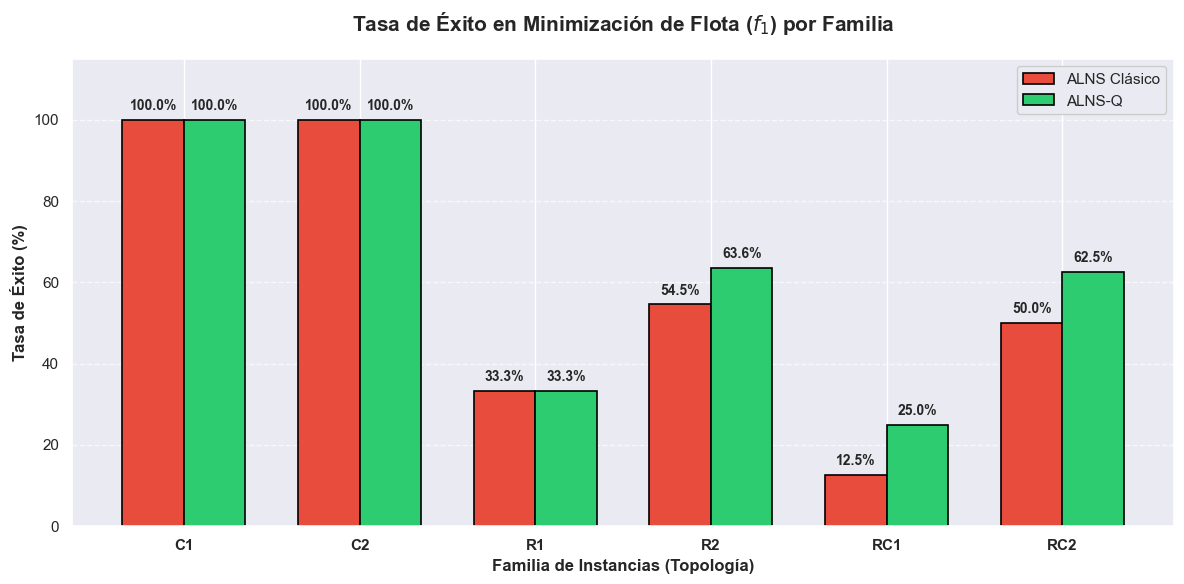

In [6]:
familias = df_exito['Familia']
tasa_c = df_exito['CLASSIC_Tasa_Exito (%)']
tasa_q = df_exito['QLEARNING_Tasa_Exito (%)']

x = np.arange(len(familias))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

barras_c = ax.bar(x - width/2, tasa_c, width, label='ALNS Clásico', 
                  color='#e74c3c', edgecolor='black', linewidth=1.2)
barras_q = ax.bar(x + width/2, tasa_q, width, label='ALNS-Q', 
                  color='#2ecc71', edgecolor='black', linewidth=1.2)

ax.set_title('Tasa de Éxito en Minimización de Flota ($f_1$) por Familia', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Familia de Instancias (Topología)', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(familias, fontsize=11, fontweight='bold')

ax.set_ylim(0, 115) 
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper right', fontsize=11, framealpha=1)

def autolabel(barras):
    for barra in barras:
        altura = barra.get_height()
        if altura > 0:
            ax.annotate(f'{altura:.1f}%',
                        xy=(barra.get_x() + barra.get_width() / 2, altura),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom', 
                        fontsize=10, fontweight='bold')

autolabel(barras_c)
autolabel(barras_q)

plt.tight_layout()
plt.savefig("imgs/Barplot_Exito_f1.png", dpi=300, bbox_inches='tight')
plt.show()

---

### Asignación de flota $f_1$

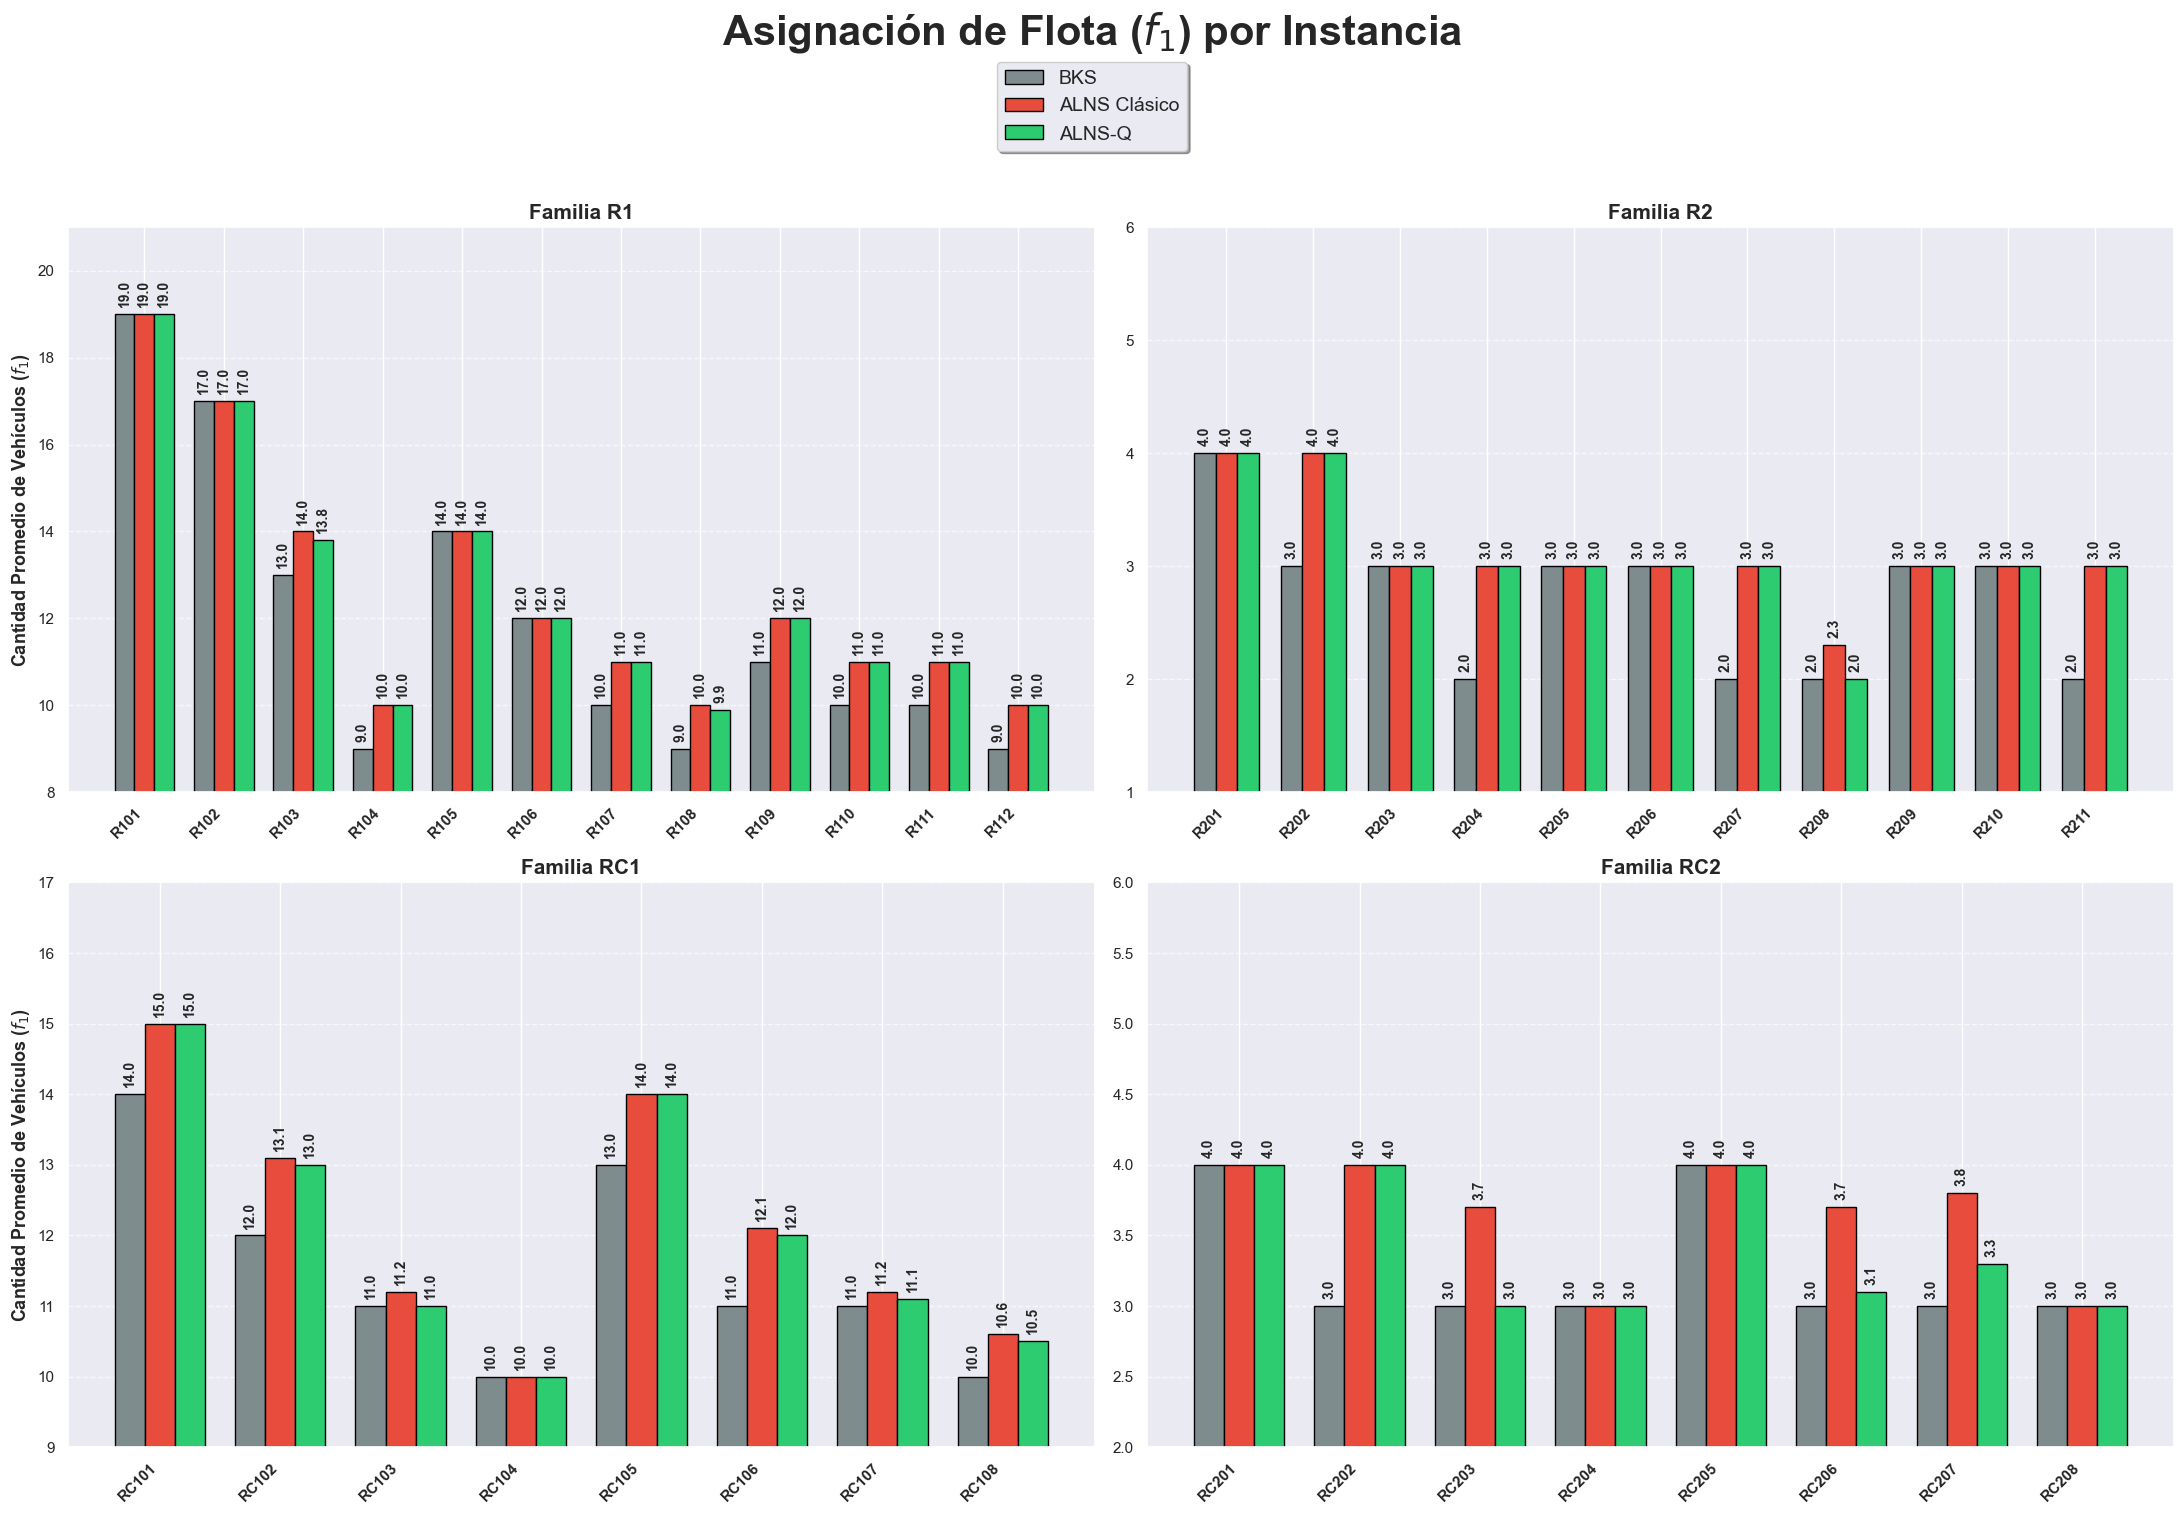

In [7]:
df_panel = df_final.copy()
familias_plot = ['R1', 'R2', 'RC1', 'RC2']
df_panel = df_panel[df_panel['Familia'].isin(familias_plot)]

fig, axs = plt.subplots(2, 2, figsize=(22, 14), sharey=False)
axs = axs.flatten()
width = 0.25

def autolabel(ax, barras):
    for barra in barras:
        altura = barra.get_height()
        ax.annotate(f'{altura:.1f}',
                    xy=(barra.get_x() + barra.get_width() / 2, altura),
                    xytext=(0, 5),  
                    textcoords="offset points",
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', rotation=90)

for i, fam in enumerate(familias_plot):
    df_f = df_panel[df_panel['Familia'] == fam].sort_values('Instancia')
    instancias = df_f['Instancia'].str.upper()
    x = np.arange(len(instancias))
    
    veh_bks = df_f['BKS_Veh']
    veh_c = df_f['CLASSIC_Vehiculos']
    veh_q = df_f['QLEARNING_Vehiculos']
    
    bar_bks = axs[i].bar(x - width, veh_bks, width, 
               label='BKS', color='#7f8c8d', edgecolor='black', linewidth=1)
    bar_alns = axs[i].bar(x, veh_c, width, 
               label='ALNS Clásico', color='#e74c3c', edgecolor='black', linewidth=1)
    bar_alnsq = axs[i].bar(x + width, veh_q, width, 
               label='ALNS-Q', color='#2ecc71', edgecolor='black', linewidth=1)
    
    autolabel(axs[i], bar_bks)
    autolabel(axs[i], bar_alns)
    autolabel(axs[i], bar_alnsq)
    
    axs[i].set_title(f'Familia {fam}', fontsize=15, fontweight='bold')
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(instancias, rotation=45, ha='right', fontsize=11, fontweight='bold')
    axs[i].grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
    
    min_veh = min(veh_bks.min(), veh_c.min(), veh_q.min())
    max_veh = max(veh_bks.max(), veh_c.max(), veh_q.max())
    lim_inf = max(0, math.floor(min_veh) - 1)
    lim_sup = math.ceil(max_veh) + 2

    axs[i].set_ylim(lim_inf, lim_sup)
    
axs[0].set_ylabel('Cantidad Promedio de Vehículos ($f_1$)', fontsize=13, fontweight='bold')
axs[2].set_ylabel('Cantidad Promedio de Vehículos ($f_1$)', fontsize=13, fontweight='bold')

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=1, fontsize=14, 
           bbox_to_anchor=(0.5, 1.05), framealpha=1, shadow=True)

plt.suptitle('Asignación de Flota ($f_1$) por Instancia', 
             fontsize=30, fontweight='bold', y=1.08)

plt.tight_layout()
plt.savefig("imgs/Flota_BKS_ALNS_ALNSQ.png", dpi=300, bbox_inches='tight')
plt.show()

---

### Calidad de rutas (GAP $f_2$) con flota mínima

In [8]:
def dibujar_dumbbells(ax, df_subset, titulo, es_mixto=False):
    if df_subset.empty:
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.text(0.5, 0.5, 'Sin instancias válidas', ha='center', va='center', fontsize=12)
        return

    df_subset = df_subset.sort_values('Instancia', ascending=False).reset_index()
    
    y_pos = np.arange(len(df_subset))
    gaps_c = df_subset['CLASSIC_GAP_f2(%)']
    gaps_q = df_subset['QLEARNING_GAP_f2(%)']
    instancias = df_subset['Instancia'].str.upper()
    familias = df_subset['Familia']

    ax.hlines(y=y_pos, xmin=np.minimum(gaps_c, gaps_q), xmax=np.maximum(gaps_c, gaps_q), 
              color='gray', alpha=0.5, linewidth=2, zorder=1)

    ax.scatter(gaps_c, y_pos, color='#e74c3c', s=120, label='ALNS Clásico', 
               edgecolor='black', zorder=3, marker='o')
    ax.scatter(gaps_q, y_pos, color='#2ecc71', s=120, label='ALNS-Q', 
               edgecolor='black', zorder=3, marker='o')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(instancias, fontsize=11, fontweight='bold')
    
    if es_mixto:
        for i, tick_label in enumerate(ax.get_yticklabels()):
            if familias.iloc[i].endswith('1'):
                tick_label.set_color('#2c3e50')
            else:
                tick_label.set_color('#7f8c8d')

    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    
    ax.axvline(0, color='black', linestyle=':', linewidth=1.5, zorder=0)

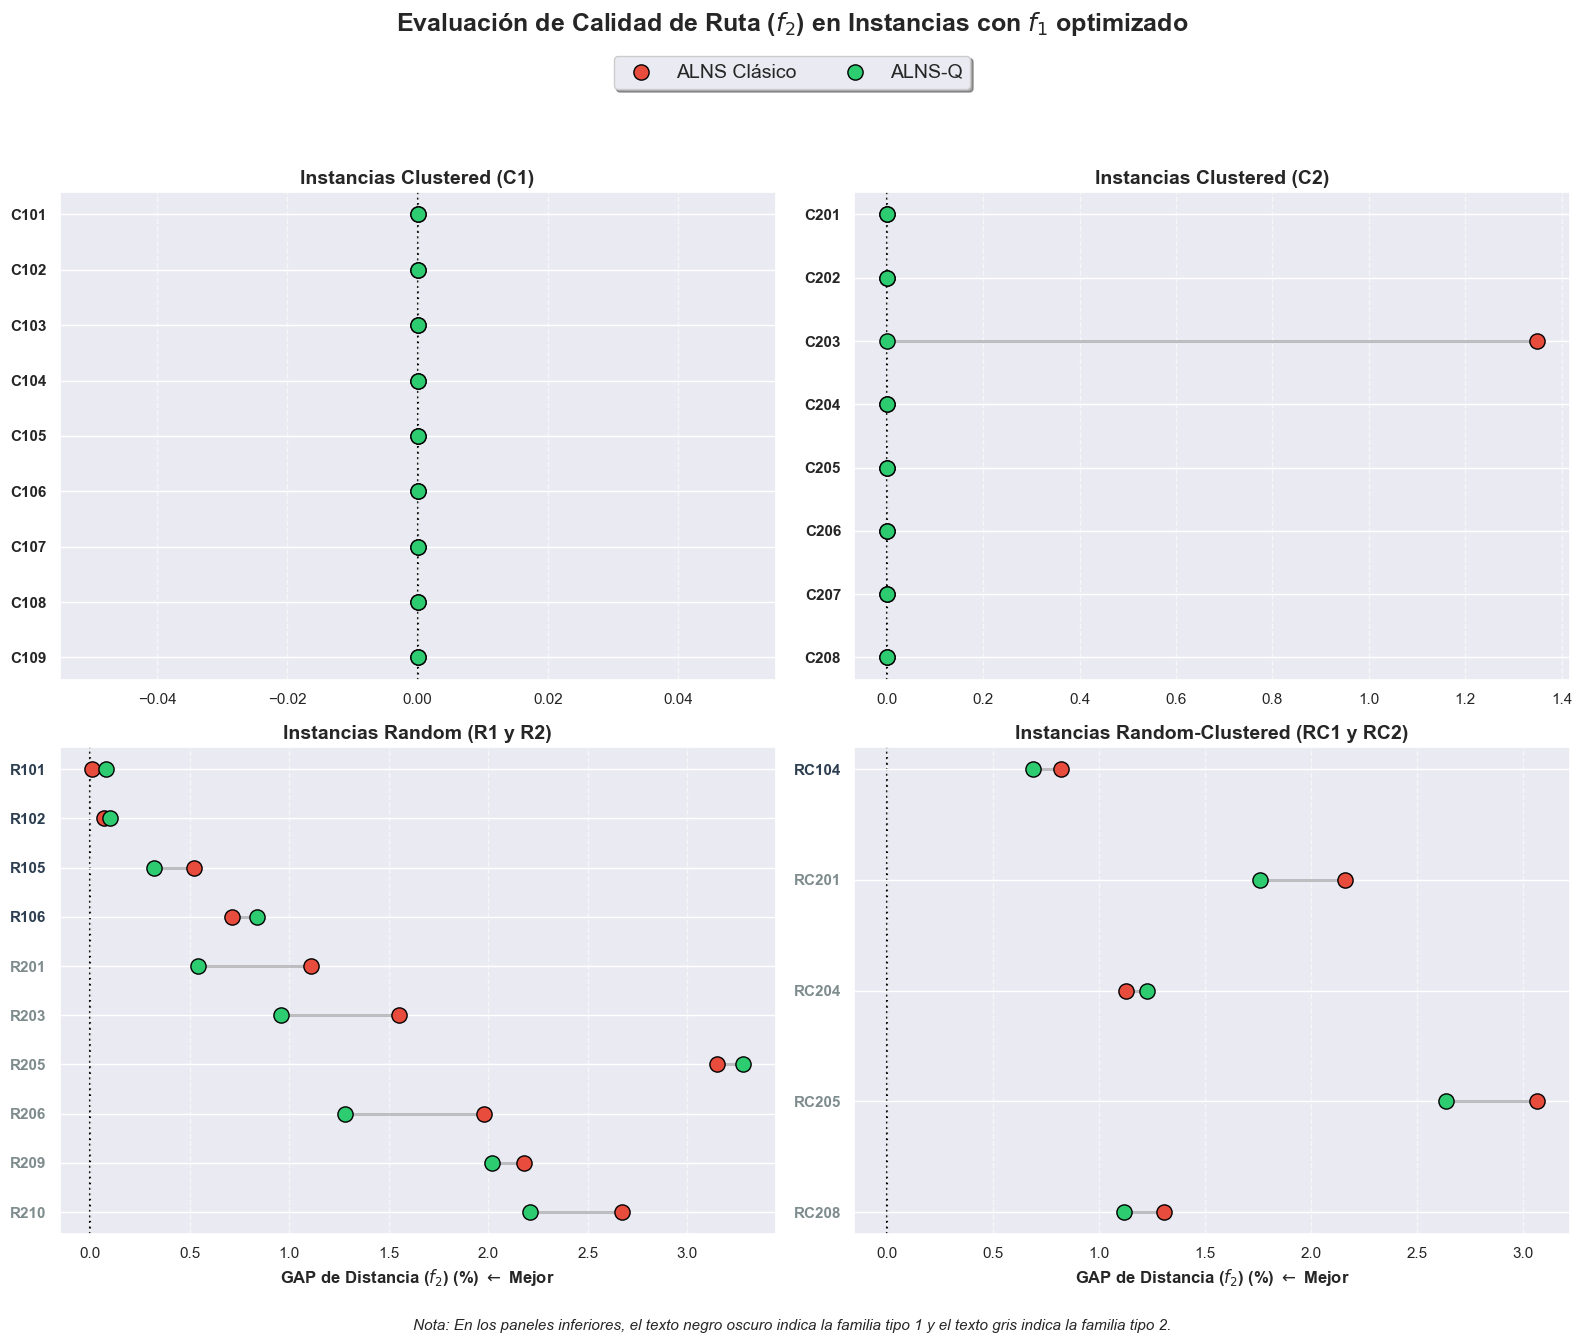

In [9]:
df_db = df_final.dropna(subset=['CLASSIC_GAP_f2(%)', 'QLEARNING_GAP_f2(%)']).copy()

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

df_c1 = df_db[df_db['Familia'] == 'C1']
dibujar_dumbbells(axs[0, 0], df_c1, 'Instancias Clustered (C1)')

df_c2 = df_db[df_db['Familia'] == 'C2']
dibujar_dumbbells(axs[0, 1], df_c2, 'Instancias Clustered (C2)')

df_r = df_db[df_db['Familia'].isin(['R1', 'R2'])]
dibujar_dumbbells(axs[1, 0], df_r, 'Instancias Random (R1 y R2)', es_mixto=True)

df_rc = df_db[df_db['Familia'].isin(['RC1', 'RC2'])]
dibujar_dumbbells(axs[1, 1], df_rc, 'Instancias Random-Clustered (RC1 y RC2)', es_mixto=True)

axs[1, 0].set_xlabel('GAP de Distancia ($f_2$) (%) $\leftarrow$ Mejor', fontsize=12, fontweight='bold')
axs[1, 1].set_xlabel('GAP de Distancia ($f_2$) (%) $\leftarrow$ Mejor', fontsize=12, fontweight='bold')

handles, labels = axs[1, 1].get_legend_handles_labels()

by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=2, 
           fontsize=14, bbox_to_anchor=(0.5, 1.05), framealpha=1, shadow=True)

plt.suptitle('Evaluación de Calidad de Ruta ($f_2$) en Instancias con $f_1$ optimizado', 
             fontsize=18, fontweight='bold', y=1.08)

fig.text(0.5, -0.02, 'Nota: En los paneles inferiores, el texto negro oscuro indica la familia tipo 1 y el texto gris indica la familia tipo 2.', 
         ha='center', fontsize=11, fontstyle='italic')

plt.tight_layout()
plt.savefig("imgs/Dumbbells_Eval_f2.png", dpi=300, bbox_inches='tight')
plt.show()

---

### Comparación de distancias (GAP $f_2$)

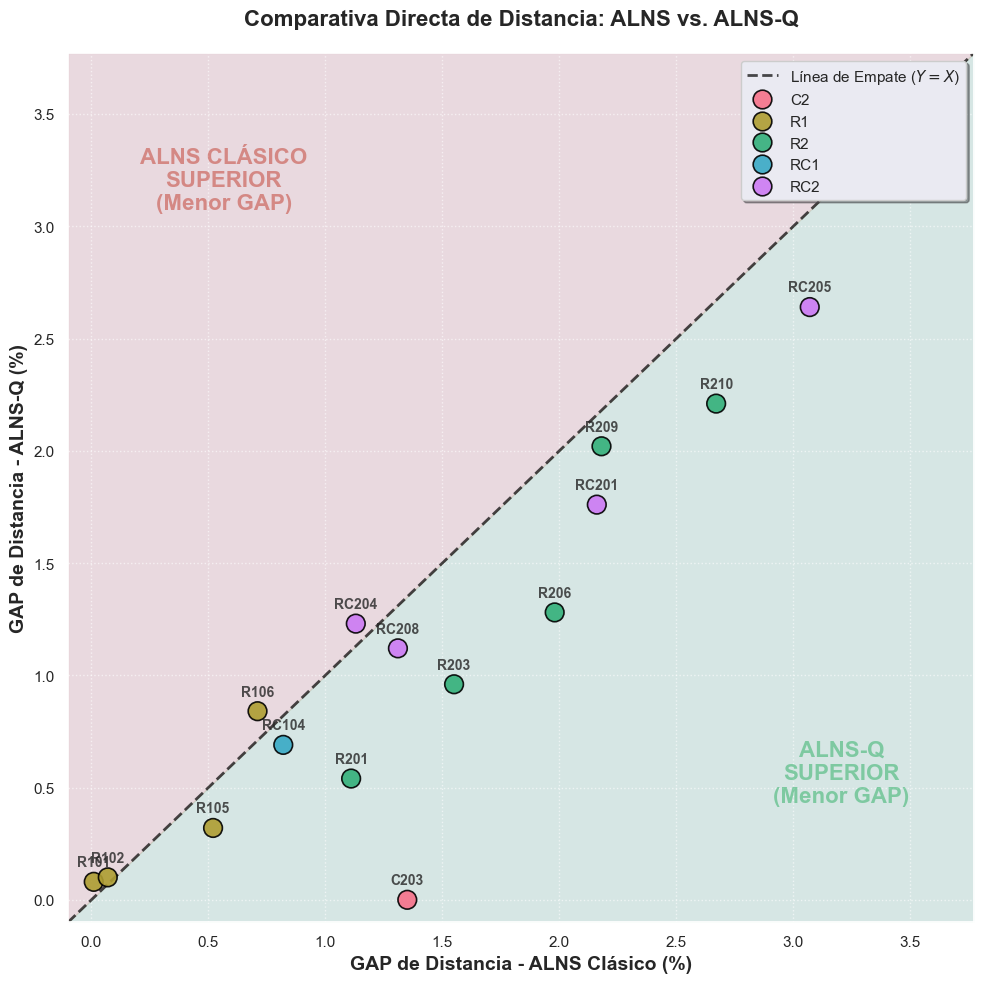

In [10]:
df_paridad = df_final.dropna(subset=['CLASSIC_GAP_f2(%)', 'QLEARNING_GAP_f2(%)']).copy()

mask_empate_cero = (df_paridad['CLASSIC_GAP_f2(%)'] == 0) & (df_paridad['QLEARNING_GAP_f2(%)'] == 0)
df_paridad = df_paridad[~mask_empate_cero].reset_index(drop=True)

plt.figure(figsize=(10, 10))

max_gap = max(df_paridad['CLASSIC_GAP_f2(%)'].max(), df_paridad['QLEARNING_GAP_f2(%)'].max())
limite = max_gap * 1.15
limite_inferior = -0.1

plt.fill_between([limite_inferior, limite], [limite_inferior, limite], limite_inferior, 
                 color='#2ecc71', alpha=0.1, zorder=0)

plt.fill_between([limite_inferior, limite], limite, [limite_inferior, limite], 
                 color='#e74c3c', alpha=0.1, zorder=0)

plt.plot([limite_inferior, limite], [limite_inferior, limite], 
         color='black', linestyle='--', linewidth=2, alpha=0.7, zorder=1, label='Línea de Empate ($Y = X$)')

sns.scatterplot(
    data=df_paridad, 
    x='CLASSIC_GAP_f2(%)', 
    y='QLEARNING_GAP_f2(%)',
    hue='Familia',
    palette=sns.color_palette("husl", len(df_paridad['Familia'].unique())),
    s=180, 
    edgecolor='black', 
    linewidth=1.2,
    alpha=0.9,
    zorder=3
)

for i, fila in df_paridad.iterrows():
    plt.text(fila['CLASSIC_GAP_f2(%)'], fila['QLEARNING_GAP_f2(%)'] + (limite*0.015), 
             fila['Instancia'].upper(), 
             fontsize=10, fontweight='bold', ha='center', va='bottom', alpha=0.8, zorder=4)

plt.text(limite * 0.85, limite * 0.15, 'ALNS-Q\nSUPERIOR\n(Menor GAP)', 
         color='#27ae60', fontsize=16, fontweight='bold', ha='center', va='center', alpha=0.5)
plt.text(limite * 0.15, limite * 0.85, 'ALNS CLÁSICO\nSUPERIOR\n(Menor GAP)', 
         color='#c0392b', fontsize=16, fontweight='bold', ha='center', va='center', alpha=0.5)

plt.title('Comparativa Directa de Distancia: ALNS vs. ALNS-Q', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('GAP de Distancia - ALNS Clásico (%)', fontsize=14, fontweight='bold')
plt.ylabel('GAP de Distancia - ALNS-Q (%)', fontsize=14, fontweight='bold')

plt.xlim(limite_inferior, limite)
plt.ylim(limite_inferior, limite)
plt.grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.legend(loc='upper right', framealpha=1, shadow=True, fontsize=11)

plt.tight_layout()
plt.savefig("imgs/Scatter_Comp_f2.png", dpi=300, bbox_inches='tight')
plt.show()

---

### Marcador cara a cara: ALNS vs ALNS-Q

In [11]:
def evaluar_enfrentamiento(row):
    v_c = row['CLASSIC_Vehiculos']
    v_q = row['QLEARNING_Vehiculos']
    d_c = row['CLASSIC_Distancia']
    d_q = row['QLEARNING_Distancia']
    
    # f_1
    if v_q < v_c:
        return 'Victoria'
    elif v_q > v_c:
        return 'Derrota'
    else:
        # f_2
        if d_q < d_c:
            return 'Victoria'
        elif d_q > d_c:
            return 'Derrota'
        else:
            return 'Empate'

In [12]:
df_wtl = df_final.copy()

df_wtl['Resultado_Q'] = df_wtl.apply(evaluar_enfrentamiento, axis=1)

marcador = pd.crosstab(df_wtl['Familia'], df_wtl['Resultado_Q'])

for col in ['Victoria', 'Empate', 'Derrota']:
    if col not in marcador:
        marcador[col] = 0

marcador = marcador[['Victoria', 'Empate', 'Derrota']]

marcador.loc['TOTAL'] = marcador.sum()

print("="*50)
print("MARCADOR FINAL: ALNS-Q vs ALNS Clásico")
print("="*50)
display(marcador)

MARCADOR FINAL: ALNS-Q vs ALNS Clásico


Resultado_Q,Victoria,Empate,Derrota
Familia,,,
C1,0,9,0
C2,1,7,0
R1,6,0,6
R2,10,0,1
RC1,7,0,1
RC2,7,0,1
TOTAL,31,16,9


---

### Distribución de tiempos de ejecución

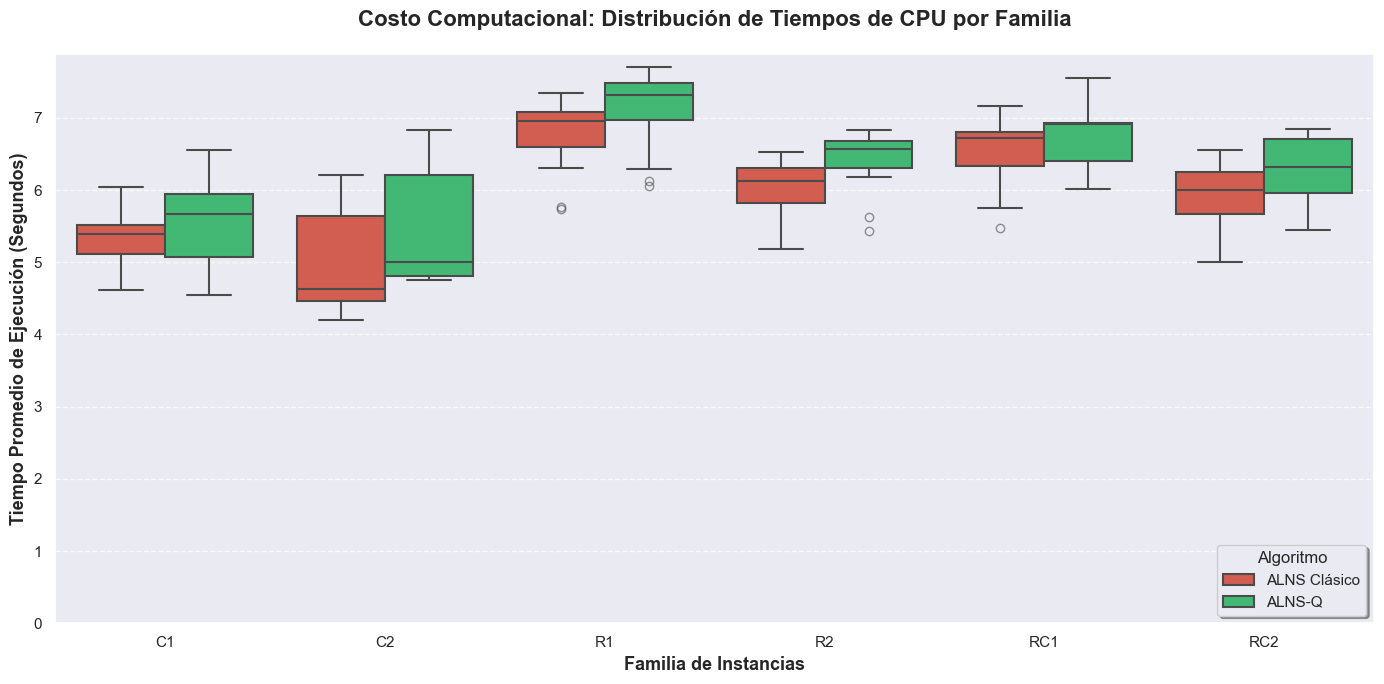

In [13]:
col_tiempo_c = 'CLASSIC_Tiempo_s' 
col_tiempo_q = 'QLEARNING_Tiempo_s'

df_time_c = df_final[['Familia', col_tiempo_c]].copy()
df_time_c['Algoritmo'] = 'ALNS Clásico'
df_time_c.rename(columns={col_tiempo_c: 'Tiempo_CPU'}, inplace=True)

df_time_q = df_final[['Familia', col_tiempo_q]].copy()
df_time_q['Algoritmo'] = 'ALNS-Q'
df_time_q.rename(columns={col_tiempo_q: 'Tiempo_CPU'}, inplace=True)

df_box_time = pd.concat([df_time_c, df_time_q], ignore_index=True)

orden_familias = ['C1', 'C2', 'R1', 'R2', 'RC1', 'RC2']

plt.figure(figsize=(14, 7))

ax = sns.boxplot(
    data=df_box_time, 
    x='Familia', 
    y='Tiempo_CPU', 
    hue='Algoritmo',
    order=orden_familias,
    palette=['#e74c3c', '#2ecc71'],
    linewidth=1.5,
    flierprops={'marker': 'o', 'markersize': 6, 'alpha': 0.6}
)

plt.title('Costo Computacional: Distribución de Tiempos de CPU por Familia', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Familia de Instancias', fontsize=13, fontweight='bold')
plt.ylabel('Tiempo Promedio de Ejecución (Segundos)', fontsize=13, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(bottom=0)

plt.legend(title='Algoritmo', loc='lower right', fontsize=11, title_fontsize=12, shadow=True)

plt.tight_layout()
plt.savefig("imgs/Boxplot_Tiempos_CPU.png", dpi=300, bbox_inches='tight')
plt.show()

---

### Trade-Off computacional

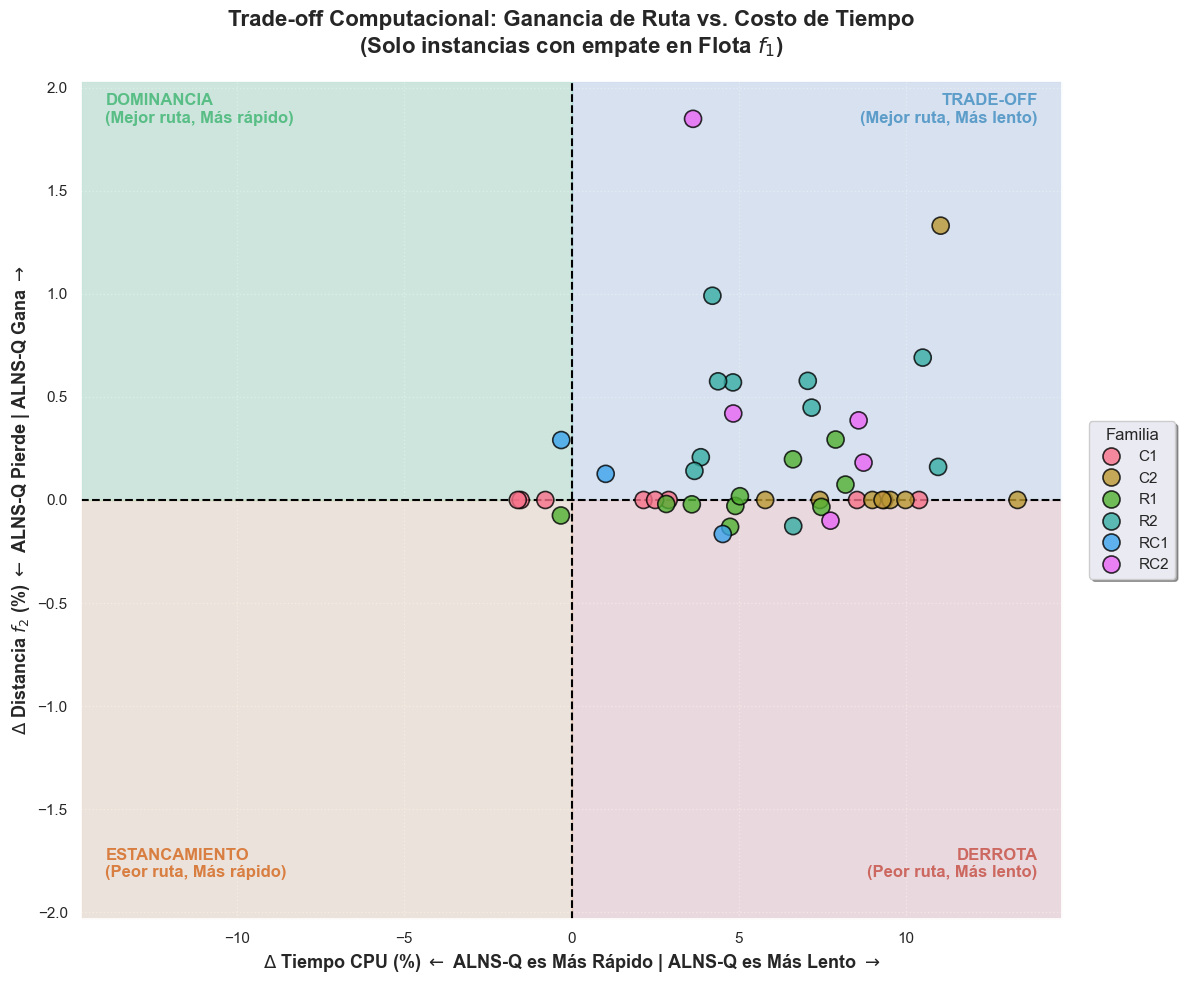

In [14]:
df_tradeoff = df_final[df_final['CLASSIC_Vehiculos'] == df_final['QLEARNING_Vehiculos']].copy()

col_tiempo_c = 'CLASSIC_Tiempo_s' 
col_tiempo_q = 'QLEARNING_Tiempo_s'

df_tradeoff['Delta_Tiempo(%)'] = ((df_tradeoff[col_tiempo_q] - df_tradeoff[col_tiempo_c]) / df_tradeoff[col_tiempo_c]) * 100
df_tradeoff['Delta_Distancia(%)'] = ((df_tradeoff['CLASSIC_Distancia'] - df_tradeoff['QLEARNING_Distancia']) / df_tradeoff['CLASSIC_Distancia']) * 100

plt.figure(figsize=(12, 10))

max_x = max(abs(df_tradeoff['Delta_Tiempo(%)'].min()), abs(df_tradeoff['Delta_Tiempo(%)'].max())) * 1.1
max_y = max(abs(df_tradeoff['Delta_Distancia(%)'].min()), abs(df_tradeoff['Delta_Distancia(%)'].max())) * 1.1

if max_y < 1: 
    max_y = 1.0

plt.fill_between([-max_x, 0], 0, max_y, color='#2ecc71', alpha=0.15)
plt.text(-max_x*0.95, max_y*0.9, 'DOMINANCIA\n(Mejor ruta, Más rápido)', color='#27ae60', fontsize=12, fontweight='bold', alpha=0.7)

plt.fill_between([0, max_x], 0, max_y, color='#3498db', alpha=0.1)
plt.text(max_x*0.95, max_y*0.9, 'TRADE-OFF\n(Mejor ruta, Más lento)', color='#2980b9', ha='right', fontsize=12, fontweight='bold', alpha=0.7)

plt.fill_between([-max_x, 0], -max_y, 0, color='#f39c12', alpha=0.1)
plt.text(-max_x*0.95, -max_y*0.9, 'ESTANCAMIENTO\n(Peor ruta, Más rápido)', color='#d35400', fontsize=12, fontweight='bold', alpha=0.7)

plt.fill_between([0, max_x], -max_y, 0, color='#e74c3c', alpha=0.1)
plt.text(max_x*0.95, -max_y*0.9, 'DERROTA\n(Peor ruta, Más lento)', color='#c0392b', ha='right', fontsize=12, fontweight='bold', alpha=0.7)

plt.axhline(0, color='black', linewidth=1.5, linestyle='--', zorder=1)
plt.axvline(0, color='black', linewidth=1.5, linestyle='--', zorder=1)

sns.scatterplot(
    data=df_tradeoff, 
    x='Delta_Tiempo(%)', 
    y='Delta_Distancia(%)',
    hue='Familia',
    palette=sns.color_palette("husl", len(df_tradeoff['Familia'].unique())),
    s=150, 
    edgecolor='black', 
    linewidth=1.2,
    alpha=0.8,
    zorder=3
)

plt.title('Trade-off Computacional: Ganancia de Ruta vs. Costo de Tiempo\n(Solo instancias con empate en Flota $f_1$)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('$\Delta$ Tiempo CPU (%) $\leftarrow$ ALNS-Q es Más Rápido | ALNS-Q es Más Lento $\\rightarrow$', fontsize=13, fontweight='bold')
plt.ylabel('$\Delta$ Distancia $f_2$ (%) $\leftarrow$ ALNS-Q Pierde | ALNS-Q Gana $\\rightarrow$', fontsize=13, fontweight='bold')

plt.xlim(-max_x, max_x)
plt.ylim(-max_y, max_y)
plt.grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), framealpha=1, shadow=True, title='Familia')

plt.tight_layout()
plt.savefig("imgs/Scatter_Tradeoff_Comp.png", dpi=300, bbox_inches='tight')
plt.show()

---

### Gráficos de instancias (ALNS vs ALNS-Q)

In [ ]:
def leer_metricas_seguro(ruta, num_columnas_esperadas):
    datos = []
    try:
        with open(ruta, 'r', encoding='utf-8') as f:
            lector = csv.reader(f)
            header = next(lector)
            datos.append(header)
            
            for fila in lector:
                if len(fila) == num_columnas_esperadas:
                    datos.append(fila)
                else:
                    break
                    
        df = pd.DataFrame(datos[1:], columns=datos[0])
        return df.apply(pd.to_numeric, errors='coerce')
        
    except FileNotFoundError:
        print(f"[ERROR] No se encontró el archivo: {ruta}")
        return None
    
def extraer_matrices_q(ruta_archivo):
    q_destruccion = []
    q_reparacion = []
    
    leyendo_destruccion = False
    leyendo_reparacion = False
    
    with open(ruta_archivo, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        linea = linea.strip()
        if not linea: continue
            
        if "MATRIZ_Q_DESTRUCCION" in linea:
            leyendo_destruccion = True
            leyendo_reparacion = False
            continue
        elif "MATRIZ_Q_REPARACION" in linea:
            leyendo_destruccion = False
            leyendo_reparacion = True
            continue
            
        if leyendo_destruccion or leyendo_reparacion:
            try:
                valores = [float(x) for x in linea.replace(',', ' ').split()][1:]
                if valores:
                    if leyendo_destruccion:
                        q_destruccion.append(valores)
                    elif leyendo_reparacion:
                        q_reparacion.append(valores)
            except ValueError:
                pass
                
    return np.array(q_destruccion), np.array(q_reparacion)

In [ ]:
# Comparacion f_2
def compare_run_auto(path_c, path_q, bks_dist, bks_veh, inst, max_iter, veh_c, veh_q):
    df_c = leer_metricas_seguro(path_c, 17)
    df_q = leer_metricas_seguro(path_q, 18)
    
    if df_c is None or df_q is None: return
        
    plt.figure(figsize=(10, 6))
    
    label_c = f'ALNS Clásico (Veh: {veh_c:.0f})'
    label_q = f'ALNS-Q (Veh: {veh_q:.0f})'
    
    plt.step(df_c['iter'], df_c['best_dist'], where='post', label=label_c, color='#e74c3c', linewidth=1.5)
    plt.step(df_q['iter'], df_q['best_dist'], where='post', label=label_q, color='#2ecc71', linewidth=1.5)
    
    min_veh_c = df_c['best_veh'].min()
    min_dist_c = df_c[df_c['best_veh'] == min_veh_c]['best_dist'].min()
    iter_opt_c = df_c[(df_c['best_veh'] == min_veh_c) & (df_c['best_dist'] == min_dist_c)]['iter'].iloc[0]
    
    min_veh_q = df_q['best_veh'].min()
    min_dist_q = df_q[df_q['best_veh'] == min_veh_q]['best_dist'].min()
    iter_opt_q = df_q[(df_q['best_veh'] == min_veh_q) & (df_q['best_dist'] == min_dist_q)]['iter'].iloc[0]
    
    plt.axvline(iter_opt_c, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.8, 
                label=f'Hito CLASSIC (Iter {iter_opt_c} | Dist: {min_dist_c})')
    plt.axvline(iter_opt_q, color='#2ecc71', linestyle=':', linewidth=1.5, alpha=0.8, 
                label=f'Hito ALNS-Q (Iter {iter_opt_q} | Dist: {min_dist_q})')
    
    label_bks = f'BKS SINTEF (Veh: {bks_veh:.0f} | Dist: {bks_dist})'
    plt.axhline(bks_dist, color='black', linestyle='--', linewidth=1, label=label_bks)
                
    plt.title(f'Convergencia de distancia ($f_2$) \nInstancia {inst.upper()}', 
              fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Iteraciones de Búsqueda', fontsize=12, fontweight='bold')
    plt.ylabel('Costo de la Ruta (Distancia)', fontsize=12, fontweight='bold')
    
    plt.xlim(0, max_iter * 1.05)
    
    plt.legend(fontsize='11', loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    fam_dir = f"../Graficos/graficos_convergencia/{inst[:-2]}"
    
    os.makedirs(fam_dir, exist_ok=True)
    plt.savefig(f"{fam_dir}/Convergencia_{inst}.png", dpi=300)
    plt.close()

# Comparacion Operadores
def plotear_politicas_operadores(path_c, path_q, instance_name, max_iter, ventana=500):
    df_classic = leer_metricas_seguro(path_c, 17)
    df_qlearning = leer_metricas_seguro(path_q, 18)
    
    if df_classic is None or df_qlearning is None: return

    cols_d = ['d_weight_0', 'd_weight_1', 'd_weight_2', 'd_weight_3']
    cols_r = ['r_weight_0', 'r_weight_1', 'r_weight_2', 'r_weight_3']
    
    nombres_d = ['Random Removal', 'Route Removal', 'Worst Removal', 'Shaw Removal']
    nombres_r = ['Greedy Insertion', 'Regret-2 Insertion', 'Regret-3 Insertion', 'Perturbed Greedy Insertion']
    
    colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

    suma_d_c = df_classic[cols_d].sum(axis=1)
    suma_r_c = df_classic[cols_r].sum(axis=1)

    for col in cols_d: df_classic[f'prob_{col}'] = df_classic[col] / suma_d_c
    for col in cols_r: df_classic[f'prob_{col}'] = df_classic[col] / suma_r_c

    for col in cols_d + cols_r:
        df_qlearning[f'prob_{col}'] = df_qlearning[col]

    todas_probs = [f'prob_{col}' for col in cols_d + cols_r]
    
    df_c_smooth = df_classic[todas_probs].rolling(window=ventana, min_periods=1).mean()
    df_q_smooth = df_qlearning[todas_probs].rolling(window=ventana, min_periods=1).mean()
    
    min_veh_c = df_classic['best_veh'].min()
    min_dist_c = df_classic[df_classic['best_veh'] == min_veh_c]['best_dist'].min()
    iter_opt_c = df_classic[(df_classic['best_veh'] == min_veh_c) & (df_classic['best_dist'] == min_dist_c)]['iter'].iloc[0]
    
    min_veh_q = df_qlearning['best_veh'].min()
    min_dist_q = df_qlearning[df_qlearning['best_veh'] == min_veh_q]['best_dist'].min()
    iter_opt_q = df_qlearning[(df_qlearning['best_veh'] == min_veh_q) & (df_qlearning['best_dist'] == min_dist_q)]['iter'].iloc[0]

    fig, axs = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
    
    for i, col in enumerate(cols_d):
        axs[0, 0].plot(df_classic['iter'], df_c_smooth[f'prob_{col}'], label=nombres_d[i], color=colores[i], linewidth=2)
        axs[0, 1].plot(df_qlearning['iter'], df_q_smooth[f'prob_{col}'], label=nombres_d[i], color=colores[i], linewidth=2)
        
    axs[0, 0].set_title('ALNS Clásico (Destrucción)', fontsize=13, fontweight='bold')
    axs[0, 1].set_title('ALNS-Q (Destrucción)', fontsize=13, fontweight='bold')
    axs[0, 0].set_ylabel('Probabilidad de Selección ($P_i$)', fontsize=11, fontweight='bold')

    for i, col in enumerate(cols_r):
        axs[1, 0].plot(df_classic['iter'], df_c_smooth[f'prob_{col}'], label=nombres_r[i], color=colores[i], linewidth=2)
        axs[1, 1].plot(df_qlearning['iter'], df_q_smooth[f'prob_{col}'], label=nombres_r[i], color=colores[i], linewidth=2)
        
    axs[1, 0].set_title('ALNS Clásico (Reparación)', fontsize=13, fontweight='bold')
    axs[1, 1].set_title('ALNS-Q (Reparación)', fontsize=13, fontweight='bold')
    axs[1, 0].set_ylabel('Probabilidad de Selección ($P_i$)', fontsize=11, fontweight='bold')
    
    axs[0, 0].axvline(iter_opt_c, color='black', linestyle=':', linewidth=2, alpha=0.6, label=f'Hito Óptimo ({iter_opt_c} | Dist: {min_dist_c})')
    axs[1, 0].axvline(iter_opt_c, color='black', linestyle=':', linewidth=2, alpha=0.6, label=f'Hito Óptimo ({iter_opt_c} | Dist: {min_dist_c})')
    
    axs[0, 1].axvline(iter_opt_q, color='black', linestyle=':', linewidth=2, alpha=0.6, label=f'Hito Óptimo ({iter_opt_q} | Dist: {min_dist_q})')
    axs[1, 1].axvline(iter_opt_q, color='black', linestyle=':', linewidth=2, alpha=0.6, label=f'Hito Óptimo ({iter_opt_q} | Dist: {min_dist_q})')
    
    for ax in axs.flat:
        ax.set_xlabel('Iteraciones', fontsize=11, fontweight='bold')
        ax.set_xlim(0, max_iter * 1.05)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='upper right', fontsize=8)

    plt.suptitle(f'Dinámica Interna de Selección de Operadores\nInstancia {instance_name.upper()}', 
                 fontsize=16, fontweight='bold')

    plt.tight_layout()
    fam_dir = f"../Graficos/graficos_operadores/{instance_name[:-2]}"
    os.makedirs(fam_dir, exist_ok=True)
    plt.savefig(f"{fam_dir}/Operadores_{instance_name}.png", dpi=300)
    plt.close()

# Timeline de Agente y Matrices Q
def plotear_panel_trazabilidad(ruta_q, inst, max_iter=None):
    df_q = leer_metricas_seguro(ruta_q, 18)
    q_dest, q_rep = extraer_matrices_q(ruta_q)
    
    if df_q is None or len(q_dest) == 0 or len(q_rep) == 0:
        print(f"[ERROR] No se pudo armar el panel completo para {inst}. Revisa el parser.")
        return
    
    min_veh = df_q['best_veh'].min()
    iter_f1 = df_q[df_q['best_veh'] == min_veh]['iter'].iloc[0]
    
    min_dist_condicionado = df_q[df_q['best_veh'] == min_veh]['best_dist'].min()
    iter_f2 = df_q[(df_q['best_veh'] == min_veh) & (df_q['best_dist'] == min_dist_condicionado)]['iter'].iloc[0]
    
    if max_iter:
        df_q = df_q[df_q['iter'] <= max_iter]

    ops_d = ['Random', 'Route', 'Worst', 'Shaw']
    ops_r = ['Greedy', 'Regret-2', 'Regret-3', 'Perturbed']
    
    fig = plt.figure(figsize=(14, 10))
    gs = GridSpec(2, 2, height_ratios=[1, 1.2], hspace=0.3)
    
    ax_gantt = fig.add_subplot(gs[0, :])
    ax_heat_d = fig.add_subplot(gs[1, 0])
    ax_heat_r = fig.add_subplot(gs[1, 1])

    ax_gantt.scatter(df_q['iter'], df_q['state'], c=df_q['state'], cmap='viridis', s=10, alpha=0.8, marker='s')
    ax_gantt.axvline(iter_f1, color='#e74c3c', linestyle='-', linewidth=2, alpha=0.8, 
                     label=f'Óptimo Flota $f_1$ (Veh: {min_veh:.0f}) -> Iter {iter_f1}')
    if iter_f1 != iter_f2:
        ax_gantt.axvline(iter_f2, color='#2980b9', linestyle='--', linewidth=2, alpha=0.8, 
                         label=f'Óptimo Distancia $f_2$ (Dist: {min_dist_condicionado:.2f}) -> Iter {iter_f2}')
    
    ax_gantt.set_title('Evolución de Estados Dinámicos (Percepción del Agente)', fontsize=13, fontweight='bold')
    ax_gantt.set_xlabel('Iteraciones', fontsize=11, fontweight='bold')
    ax_gantt.set_ylabel('ID del Estado', fontsize=11, fontweight='bold')
    
    estados_unicos = sorted(df_q['state'].dropna().unique())
    ax_gantt.set_yticks(estados_unicos, labels=['Mejorando (0)', 'Estancado (1)', 'Atrapado (2)'])
    ax_gantt.grid(True, linestyle='--', alpha=0.5)
    ax_gantt.legend(loc='upper right')

    sns.heatmap(q_dest, ax=ax_heat_d, cmap='YlOrRd', annot=True, fmt=".2f", 
                cbar_kws={'label': 'Valor Q Esperado'}, linewidths=.5,
                xticklabels=ops_d, yticklabels=[f"E{int(s)}" for s in estados_unicos])
    
    ax_heat_d.set_title('Matriz Q: Operadores de Destrucción', fontsize=12, fontweight='bold')
    ax_heat_d.set_xlabel('Acciones (Operadores)', fontsize=10)
    ax_heat_d.set_ylabel('Estados', fontsize=10)

    sns.heatmap(q_rep, ax=ax_heat_r, cmap='YlGnBu', annot=True, fmt=".2f", 
                cbar_kws={'label': 'Valor Q Esperado'}, linewidths=.5,
                xticklabels=ops_r, yticklabels=[f"E{int(s)}" for s in estados_unicos])
    
    ax_heat_r.set_title('Matriz Q: Operadores de Reparación', fontsize=12, fontweight='bold')
    ax_heat_r.set_xlabel('Acciones (Operadores)', fontsize=10)
    
    plt.setp(ax_heat_d.get_xticklabels(), rotation=15, ha='right')
    plt.setp(ax_heat_r.get_xticklabels(), rotation=15, ha='right')

    plt.suptitle(f'Auditoría del Agente ALNS-Q (Trazabilidad y Política Óptima)\nInstancia {inst.upper()}', 
                 fontsize=16, fontweight='bold', y=0.98)

    fam_dir = f"../Graficos/graficos_trazabilidad/{inst[:-2]}"
    os.makedirs(fam_dir, exist_ok=True)
    nombre_archivo = f'{fam_dir}/Panel_XAI_{inst}.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.close()

In [ ]:
def generar_graficos_familia(familia, df_master, df_sintef):
    print(f"Iniciando generación de gráficos para la familia {familia}...\n")

    df_fam = df_master[df_master['Familia'] == familia]
    instancias = df_fam['Instancia'].unique()
    
    for inst in instancias:
        print(f"Procesando instancia {inst.upper()}")
        try:
            bks_row = df_sintef[df_sintef['Instancia'] == inst]
            bks_dist = bks_row['BKS_Dist'].iloc[0]
            bks_veh = bks_row['BKS_Veh'].iloc[0]

            df_inst_c = df_fam[(df_fam['Instancia'] == inst) & (df_fam['Algoritmo'] == 'CLASSIC')]
            best_c = df_inst_c.sort_values(
                by=['Vehiculos', 'Distancia', 'Iter_Convergencia'],
                ascending=[True, True, True]
			).iloc[0]
            
            run_c = int(best_c['Run'])
            iter_c = best_c['Iter_Convergencia']
            veh_c = best_c['Vehiculos']

            df_inst_q = df_fam[(df_fam['Instancia'] == inst) & (df_fam['Algoritmo'] == 'QLEARNING')]
            best_q = df_inst_q.sort_values(
				by=['Vehiculos', 'Distancia', 'Iter_Convergencia'],
                ascending=[True, True, True]
			).iloc[0]
            
            run_q = int(best_q['Run'])
            iter_q = best_q['Iter_Convergencia']
            veh_q = best_q['Vehiculos']
            
            max_val = max(iter_c, iter_q)
            max_iter = math.ceil(max_val / 5.0) * 5

            if max_iter < 10: max_iter = 10 

            path_c = f"../Results/CLASSIC/metrics/CLASSIC_{inst}_metrics_run{run_c}.csv"
            path_q = f"../Results/QLEARNING/metrics/QLEARNING_{inst}_metrics_run{run_q}.csv"

            compare_run_auto(path_c, path_q, bks_dist, bks_veh, inst.upper(), max_iter, veh_c, veh_q)
            print(f"  [OK] Gráfico de Convergencia (Zoom: {max_iter})")
            plotear_politicas_operadores(path_c, path_q, inst.upper(), max_iter)
            print(f"  [OK] Cuadrícula de Operadores (Destrucción/Reparación)")
            plotear_panel_trazabilidad(path_q, inst.upper())
            print(f"  [OK] Panel de Trazabilidad XAI (Matrices Q)\n")
            
        except Exception as e:
            print(f"[ERROR] No se pudo procesar {inst.upper()}: {str(e)}")
            
    print(f"\n¡Todos los gráficos de la familia {familia} han sido guardados!")

In [ ]:
generar_graficos_familia("C1", df_master, df_sintef)
generar_graficos_familia("C2", df_master, df_sintef)
generar_graficos_familia("R1", df_master, df_sintef)
generar_graficos_familia("R2", df_master, df_sintef)
generar_graficos_familia("RC1", df_master, df_sintef)
generar_graficos_familia("RC2", df_master, df_sintef)

### Convergencia de $f_2$

### Comparación de Operadores

### Agente ALNS-Q

---

## Tests estadísticos

In [15]:
from scipy.stats import friedmanchisquare, wilcoxon

bks = df_final['BKS_Veh']
alns_c = df_final['CLASSIC_Vehiculos']
alns_q = df_final['QLEARNING_Vehiculos']

df_f2_validas = df_final.dropna(subset=['CLASSIC_GAP_f2(%)', 'QLEARNING_GAP_f2(%)']).copy()

gap_c = df_f2_validas['CLASSIC_GAP_f2(%)']
gap_q = df_f2_validas['QLEARNING_GAP_f2(%)']

tiempo_c = df_final['CLASSIC_Tiempo_s']
tiempo_q = df_final['QLEARNING_Tiempo_s']

### **Friedman:** Flota de vehiculos $f_1$ (BKS vs ALNS vs ALNS-Q)

In [16]:
stat, p_value = friedmanchisquare(bks, alns_c, alns_q)

print("="*70)
print("TEST DE FRIEDMAN: ROBUSTEZ EN LA ASIGNACIÓN DE FLOTA (f_1)")
print("="*70)
print(f"Muestra: {len(df_final)} instancias pareadas (Grupos: BKS, ALNS Clásico, ALNS-Q)")
print(f"Estadístico de prueba: {stat:.4f}")
print(f"p-value:               {p_value:.6f}")
print("-" * 70)

alpha = 0.05
if p_value > alpha:
    print(f"CONCLUSIÓN (p > {alpha}): NO se rechaza la Hipótesis Nula (Empate Estadístico)")
else:
    print(f"CONCLUSIÓN (p < {alpha}): Se rechaza la Hipótesis Nula (Diferencia Significativa)")
print("="*70)

TEST DE FRIEDMAN: ROBUSTEZ EN LA ASIGNACIÓN DE FLOTA (f_1)
Muestra: 56 instancias pareadas (Grupos: BKS, ALNS Clásico, ALNS-Q)
Estadístico de prueba: 41.8750
p-value:               0.000000
----------------------------------------------------------------------
CONCLUSIÓN (p < 0.05): Se rechaza la Hipótesis Nula (Diferencia Significativa)


### **Wilcoxon:** Flota de vehiculos $f_1$ (ALNS vs ALNS-Q)

In [17]:
stat, p_value = wilcoxon(alns_c, alns_q, zero_method='wilcox')

print("="*70)
print("TEST DE WILCOXON: ALNS Clásico vs ALNS-Q (Vehículos f_1)")
print("="*70)
print(f"Estadístico de prueba: {stat:.4f}")
print(f"p-value:               {p_value:.6f}")
print("-" * 70)

alpha = 0.05
if p_value > alpha:
    print(f"CONCLUSIÓN (p > {alpha}): NO se rechaza la Hipótesis Nula (Empate Estadístico)")
else:
    print(f"CONCLUSIÓN (p < {alpha}): Se rechaza la Hipótesis Nula (Diferencia Significativa)")
print("="*70)

TEST DE WILCOXON: ALNS Clásico vs ALNS-Q (Vehículos f_1)
Estadístico de prueba: 0.0000
p-value:               0.003027
----------------------------------------------------------------------
CONCLUSIÓN (p < 0.05): Se rechaza la Hipótesis Nula (Diferencia Significativa)


### **Wilcoxon:** Distancia recorrida $f_2$ (ALNS vs ALNS-Q)

In [18]:
stat, p_value = wilcoxon(gap_c, gap_q, zero_method='wilcox')

print("="*70)
print("TEST DE WILCOXON: CALIDAD DE RUTA CONDICIONADA (f_2)")
print("="*70)
print(f"Muestra filtrada: {len(df_f2_validas)} instancias mutuamente válidas")
print(f"Estadístico de prueba: {stat:.4f}")
print(f"p-value:               {p_value:.6f}")
print("-" * 70)

alpha = 0.05
if p_value > alpha:
    print(f"CONCLUSIÓN (p > {alpha}): NO se rechaza la Hipótesis Nula (Empate Estadístico)")
else:
    print(f"CONCLUSIÓN (p < {alpha}): Se rechaza la Hipótesis Nula (Diferencia Significativa)")
print("="*70)

TEST DE WILCOXON: CALIDAD DE RUTA CONDICIONADA (f_2)
Muestra filtrada: 32 instancias mutuamente válidas
Estadístico de prueba: 15.5000
p-value:               0.006624
----------------------------------------------------------------------
CONCLUSIÓN (p < 0.05): Se rechaza la Hipótesis Nula (Diferencia Significativa)


### **Wilcoxon:** Tiempo de CPU (ALNS vs ALNS-Q)

In [19]:
stat, p_value = wilcoxon(tiempo_c, tiempo_q, zero_method='wilcox')

print("="*70)
print("TEST DE WILCOXON: COSTO COMPUTACIONAL (Tiempo CPU)")
print("="*70)
print(f"Muestra: {len(df_final)} instancias completas")
print(f"Estadístico de prueba: {stat:.4f}")
print(f"p-value:               {p_value:.6f}")
print("-" * 70)

alpha = 0.05
if p_value > alpha:
    print(f"CONCLUSIÓN (p > {alpha}): NO se rechaza la Hipótesis Nula (Empate Estadístico)")
else:
    print(f"CONCLUSIÓN (p < {alpha}): Se rechaza la Hipótesis Nula (Diferencia Significativa)")
print("="*70)

TEST DE WILCOXON: COSTO COMPUTACIONAL (Tiempo CPU)
Muestra: 56 instancias completas
Estadístico de prueba: 16.5000
p-value:               0.000000
----------------------------------------------------------------------
CONCLUSIÓN (p < 0.05): Se rechaza la Hipótesis Nula (Diferencia Significativa)
